### Part A

**Unsupervised Hierarchical clustering using the HAC algorithm**

The goal is to cluster a dataset of small molecules using unsupervised learning. To do this, I made a class that implements a basic HAC algorithm. This algorithm involves: standardizing a each feature column of our data (I used the sklearn standard scaler), initialzing treating each sample (or row) as its own cluster, joining the closest two clusters together as a superset. This strategy is repeated until all points have been aggregated into a single cluster, or in practice until we have $n$ clusters. 

Some more details of my implementation:
- I used a class to mimic the sklearn style API used by most python based machine learning implementations
- To determine inter-cluster distance (similarity) I used the complete linkage algorithm which involves comparing the pair-wise euclidean distance (I used the squared distance for simplicity) elements in each custer, and the largest distance between two points is considered the distance between the two clusters.


We will the HAC class to group molecules by similarity of features. Then we can try clustering with the sklearn implementation to see how well we did. PCA can be performed in order to visualize high-dimensional data as clusters. 



In [1]:
# quick helper class to keep track of indices of samples 

class sample:
    """
    arr is a numpy array and i is an index (i.e. from a pandas dataframe)
    """
    def __init__(self, arr, index):
        self.arr = arr
        self.index= index

**HAC implementation**

In [2]:
import numpy as np
from sklearn.preprocessing import StandardScaler

class HAC_Clustering:
    def __init__(self, n_clusters):
        self.n_clusters = n_clusters
     
        
    def fit(self, X, standardize=False):
        '''
        returns samples (rows) from matrix X as an array of lists containing clustered samples 
        '''
        # standardize data
        if standardize: # since the dataset is already standardized - I added a boolean flag so data will only be standardized if we specify
            scaler = StandardScaler() 
            X = scaler.fit_transform(X)

        # initialize clusters from data - reach row
        # its important that we place each point in its own list 
        clusters = [[sample(X[i], i)] for i in range(X.shape[0])]

        # run a loop until our list of cluster is n_clusters long
        # the list should get shorter at each iteration 
        while len(clusters)  > self.n_clusters:
            # save best distance AND best pair so we do not have to recompute distance once we find the best pair (avoids too much nested looping)
            best_distance = np.inf # this will be distance between the closests clusters
            best_pair = (0,0) # this will be a tuple (i,j)
            
            # find the closest two clusters 
            for i in range(len(clusters)):
                for j in range(i+ 1, len(clusters)):
                    # find distance - complete linkage expects a list of numpy arrays as clusters
                    d = self.complete_linkage(clusters[i], clusters[j])
                    if d < best_distance:
                        # save best distance
                        best_distance = d
                        # save best pair
                        best_pair = (i, j)

            # merge the clusters 
            i = best_pair[0]
            j = best_pair[1]
            merged = self.merge_clusters(clusters[i], clusters[j])

            # we make a new list instead of removing clusters from the original list to avoid "out of bounds" bugs
            clusters = [clusters[n] for n in range(len(clusters)) if n!= i and n!= j]
            clusters.append(merged)
      
        return clusters

  
    # function to compute euclidian distance
    def calc_distance(self, vector_1, vector_2):
        '''
        - compute distance magnitude between any two vectors
        - both vectors must be the same shape
        '''
        dis_squared = 0
        for i in range(len(vector_1)):
            dis_squared += (vector_1[i] - vector_2[i])**2
        return dis_squared
   

    # function for pair-wise loop to return largesst distance
    def complete_linkage(self,cluster_1, cluster_2):
        '''
        A cluster is always a array/list with K number of vectors,
        cluster_1 has k num values, cluster_2 has n number of vectors
        
        the complete linkage algorithm measures the distance between two clusters as the distance between the two farthest points 

        UPDATE: cluster is a array of sample objects that have a numpy array attribute
        '''
        largest = -np.inf 
        for k in range(len(cluster_1)):
            for n in range(len(cluster_2)):
                dis_squared = self.calc_distance(cluster_1[k].arr, cluster_2[n].arr)
                if dis_squared > largest:
                    largest = dis_squared
        return largest

    def merge_clusters(self, cluster_1, cluster_2):
        return cluster_1 + cluster_2


**Analysis**

In [3]:
import pandas as pd 
from rdkit import Chem

init_sol_df = pd.read_csv("sol_data.csv")


# set index to name of the molecule so we know which samples are which
init_sol_df.index = init_sol_df["Name"]


# Im going to drop non numerical features 
sol_df = init_sol_df
columns_to_drop = ["Name", "InChIKey","ID", "SMILES", "rdkit_mol"]

for col in columns_to_drop:
    sol_df = sol_df.drop(col, axis=1)


In [4]:
# get shape of our data 
sol_df.shape # we have ~1000 small molecules and 108 descriptors as features



(998, 109)

In [5]:
# initialize our HAC class

# we will try making 10 clusters - try with 50 data points (1000 points may take a couple minutes to cluster)
hac_clustering = HAC_Clustering(n_clusters=3)

# fit the data and get a list of clustered samples 
# note to self, we dont yet have a way to get back sample names
sol_clustered = hac_clustering.fit(np.array(sol_df.head(50))) # the cluster method expects a numpy array so we should convert



In [6]:
len(sol_clustered)

3

In [7]:
# this is a list of clusters (lists)
# each element in a cluster is a "sample object" that has a numpy array and the original index
# we did it this way so we can keep track of which molecules fell into which clusters

sol_clustered[0][0].arr
sol_clustered[0][0].index



9

In [8]:
# helper functions for elbow plot 

def get_centroid(cluster):
    ''' 
    Assume all arrays in a cluster have the same length
    cluster will be a list of sample objects
    '''
    matrix = np.array([cluster[i].arr for i in range(len(cluster))])
    centroid = np.mean(matrix, axis=0)  


    return centroid

def get_total_variance(clusters):
    '''
    get total variance in a cluster - we compute a centroid from get_centroid
    -> essentially the mean sample in a cluster then we get distances from all points
    in a cluster to the centroid. Repeat this for every cluster and take the sum

    very similar implmentation to what I did in the HAC class
    '''
    total_var = 0
    for cluster in clusters:
        centroid = get_centroid(cluster)
        for point in cluster:
            for i in range(len(point.arr)):
                total_var += (centroid[i] - point.arr[i])**2

    return total_var



In [9]:
# since my implementation has a lot of loops I found iterating from greatest to least clusters works the best

# I will select a sample of 50 random points (my algorithm takes very long to cover the full dataset) 


random_indices = np.random.randint(0, 997, size=50)
sample_of_sol_df = sol_df.iloc[random_indices]


clusterings = [HAC_Clustering(i).fit(np.array(sample_of_sol_df)) for i in range(20, 1, -1)]

In [10]:
variances = [get_total_variance(clusters) for clusters in clusterings]

Text(0.5, 1.0, 'Elbow plot of solubility data clusterings')

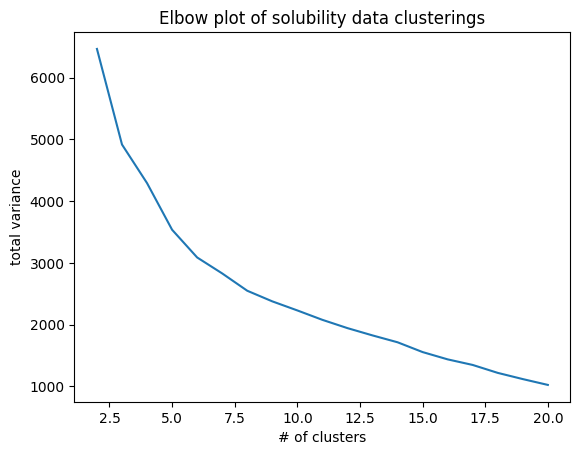

In [11]:
# elbow plot
from matplotlib import pyplot as plt 
n_clusters = np.arange(20, 1, -1)
plt.plot(n_clusters, variances)

plt.xlabel("# of clusters")
plt.ylabel("total variance")
plt.title("Elbow plot of solubility data clusterings")

**Interpreting elbow plot**
- We can see multiple sharp corners on the curve also know as elbow points
- To me it looks like the sharpest point is about at 7 clusters
- Since we select are small representation of random points from the dataset, they may cluster differently resulting in different elbow plots each time

**Cluster data into 7 groups and label the samples**


In [12]:
clustering = HAC_Clustering(n_clusters=7).fit(np.array(sample_of_sol_df))

In [13]:

# make a dictionary - key is index of sample in original data, value is the cluster the sample belongs to
label_dict = {}
for i in range(len(clustering)):
    for sample in clustering[i]:
        label_dict[sample.index] = i 


# using label dicitonary, assign index i of sol_df with cluster label
sample_of_sol_df["cluster"] = [label_dict[i] for i in range(len(sample_of_sol_df.index))]

/tmp/ipykernel_61388/3851436865.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sample_of_sol_df["cluster"] = [label_dict[i] for i in range(len(sample_of_sol_df.index))]


In [14]:
sample_of_sol_df["cluster"].head(5)

Name
isopropalin                      6
sec-butylacetate                 5
2-phenylethyl 2-phenylacetate    6
ethyl 2-ethylhexanoate           5
griseofulvin                     6
Name: cluster, dtype: int64

**Dimensionality Reduction and visualization**

In [15]:
from sklearn.decomposition import PCA 

# the solubility dataset has 100+ features so we will do dimensinality reduction with PCA to visualize our clusters in 2D
# we will skip the scaling step of PCA since the data is already scaled 

pca = PCA(n_components= 2)
X_sample_reduced = pca.fit_transform(sample_of_sol_df)
X_sample_reduced.shape

(50, 2)

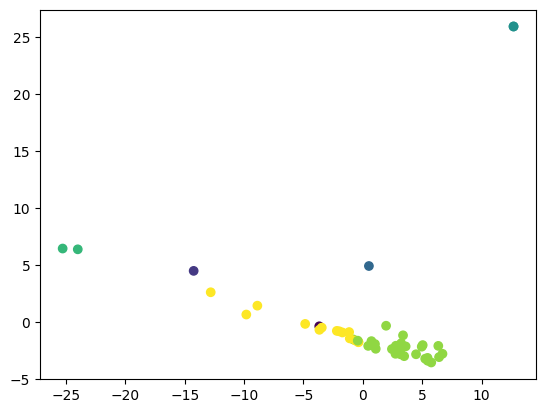

In [16]:
# plot embeddings from our dimensionality reduction

# we can color based on cluster
# the data clusters pretty nicely!
plt.scatter(X_sample_reduced[:,0], X_sample_reduced[:,1], c=sample_of_sol_df["cluster"])



In [17]:
def get_centroid_np(cluster):
    matrix = np.array([cluster[i] for i in range(len(cluster))])
    centroid = np.mean(matrix, axis=0)  
    return centroid

def get_cluster_var(cluster):
    total_var = 0
    centroid = get_centroid_np(cluster)
    for point in cluster:
        for i in range(len(point)):
            total_var += (centroid[i] - point[i])**2

    return total_var

**Using the sklearn AgglomerativeClustering algorithm on the full dataset**

- When we run fit on the data, it returns a vector where each element at index $i$ is the label for row $i$ (the cluster each sample belongs to)
- The numerical labels are determined by how many clusters to specify when we initialize the class

In [18]:
from sklearn.cluster import AgglomerativeClustering

# creating an elbow plot from 1 to 100 clusters

# to do this ill create a list of lists - containing labels for the data if clustered by n clusters ( from 10 to 100)
clusterings = [AgglomerativeClustering(n_clusters=i).fit(sol_df).labels_ for i in range(1, 110,10)]

# store variances in a list
variances = []

for clustering in clusterings:
    sol_df_temp = sol_df
    sol_df_temp["cluster"] = clustering
    
    # compute variance of each cluster
    total_var = 0
    for group in clustering:
        sol_df_temp = sol_df_temp[sol_df_temp["cluster"] == group]
        total_var += get_cluster_var(np.array(sol_df_temp))
    variances.append(total_var)


/tmp/ipykernel_61388/4142922626.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sol_df_temp["cluster"] = clustering
/home/braemp4/code/ML-for-chemistry/part2/assignments/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/braemp4/code/ML-for-chemistry/part2/assignments/venv/lib/python3.14/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Text(0.5, 1.0, 'Elbow plot of solubility data clusterings')

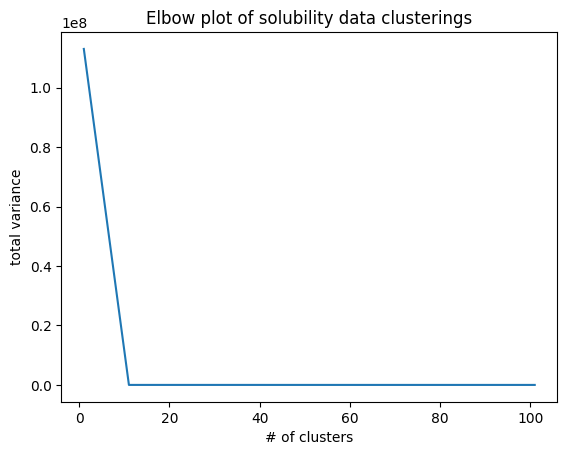

In [19]:
n_clusters = np.arange(1, 110, 10)
plt.plot(n_clusters, variances)

plt.xlabel("# of clusters")
plt.ylabel("total variance")
plt.title("Elbow plot of solubility data clusterings")
# we get a very sharp elbow point at around 17 clusters - and we seemingly decreased intra cluster variance by using the entire dataset


In [20]:
final_clustering = AgglomerativeClustering(n_clusters=17).fit(sol_df)
sol_df["cluster"] = final_clustering.labels_

**Dimensionality Reduction and visualization**
- Left figure - PCA of hierarchical clustering using using sklearn
- Right figure - PCA of hierarchical using our own implementation


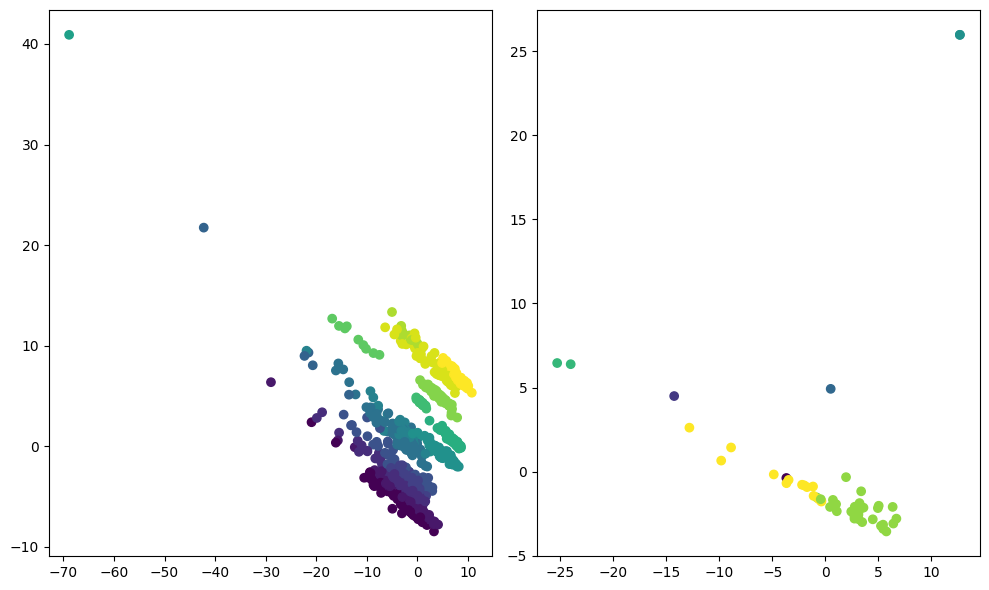

In [21]:
pca = PCA(n_components= 2)
X_reduced = pca.fit_transform(sol_df)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
axes[0].scatter(X_reduced[:,0], X_reduced[:,1], c=sol_df["cluster"])
axes[1].scatter(X_sample_reduced[:,0], X_sample_reduced[:,1], c=sample_of_sol_df["cluster"])

fig.tight_layout()